### step 1:import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### step 2:load dataset

In [32]:
import pandas as pd
df=pd.read_csv("unemployment in india.csv")
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban


### step 3:check dataset information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 41.4+ KB


### step 4:check missing values

In [5]:
df.isnull().sum()

Region                                      14
 Date                                       14
 Frequency                                  14
 Estimated Unemployment Rate (%)            14
 Estimated Employed                         14
 Estimated Labour Participation Rate (%)    14
Area                                        14
dtype: int64

### step 5:remove missing values

In [6]:
df=df.dropna()

### step 6:statistical summary

In [7]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


### step 7:check column names

In [8]:
print(df.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


### step 8:strip columns

In [13]:
df.columns=df.columns.str.strip()
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


### step 9:convert date column

In [15]:
df['Date']=pd.to_datetime(df['Date'])

C:\Users\Shubham\AppData\Local\Temp\ipykernel_24296\3023999556.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date']=pd.to_datetime(df['Date'])


### step 10:unemployment rate distribution

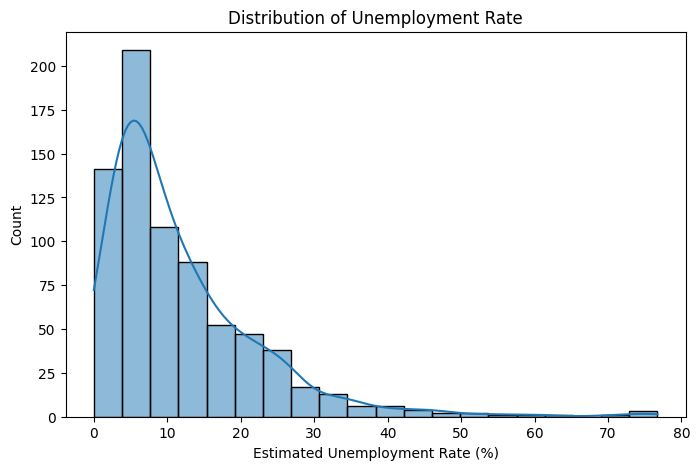

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Estimated Unemployment Rate (%)'],bins=20,kde=True)
plt.title("Distribution of Unemployment Rate")
plt.show()

### step 11:region wise average unemployment

In [18]:
region_unemployment=df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False)
region_unemployment

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

### step 12:bar chart of regions

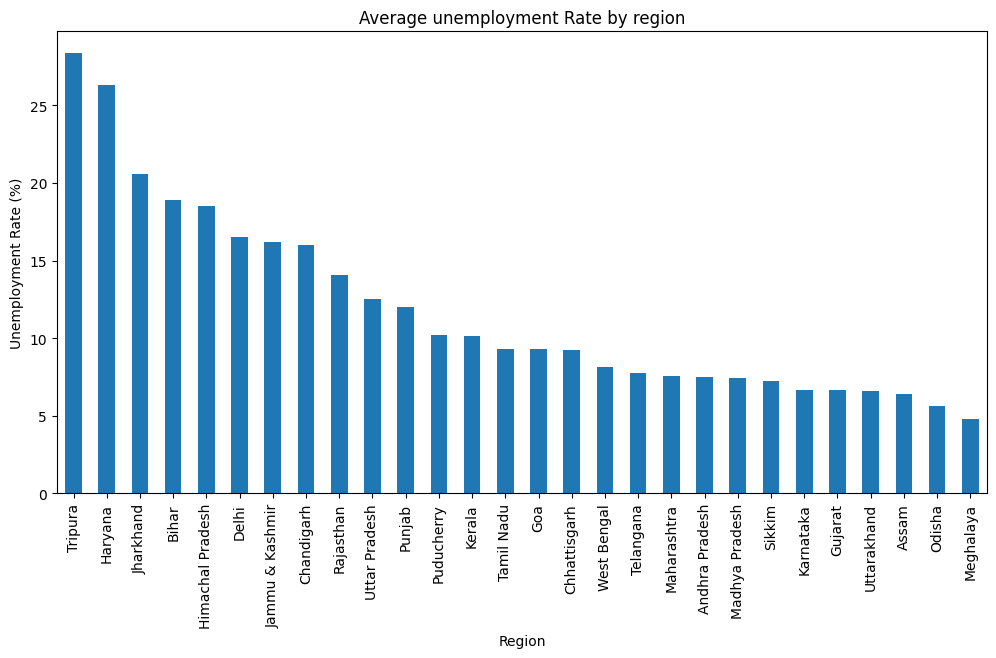

In [19]:
plt.figure(figsize=(12,6))
region_unemployment.plot(kind='bar')

plt.title("Average unemployment Rate by region")
plt.ylabel("Unemployment Rate (%)")
plt.xlabel("Region")

plt.show()

### step 13:monthly unemployment trend

In [21]:
monthly_trend=df.groupby(
    df['Date'].dt.month
)['Estimated Unemployment Rate (%)'].mean()

monthly_trend

Date
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64

### step 14:monthly trend visualization

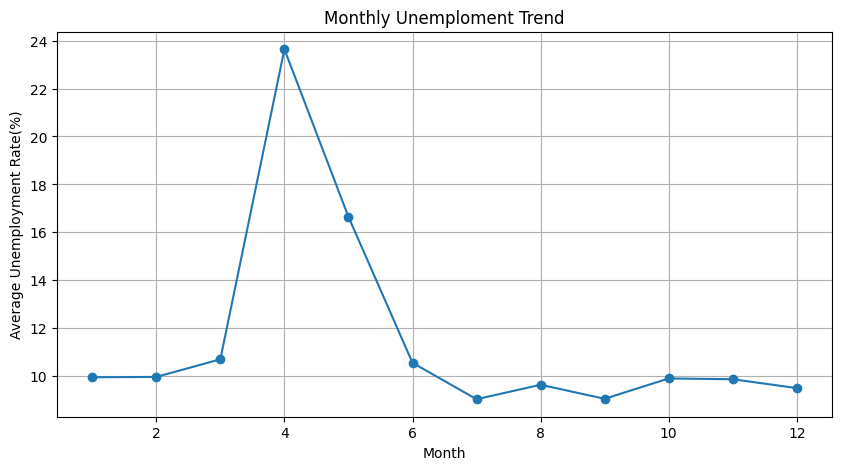

In [23]:
plt.figure(figsize=(10,5))

plt.plot(monthly_trend.index,monthly_trend.values,marker='o')

plt.title("Monthly Unemploment Trend")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate(%)")

plt.grid(True)
plt.show()

### step 15:corelation heatmap

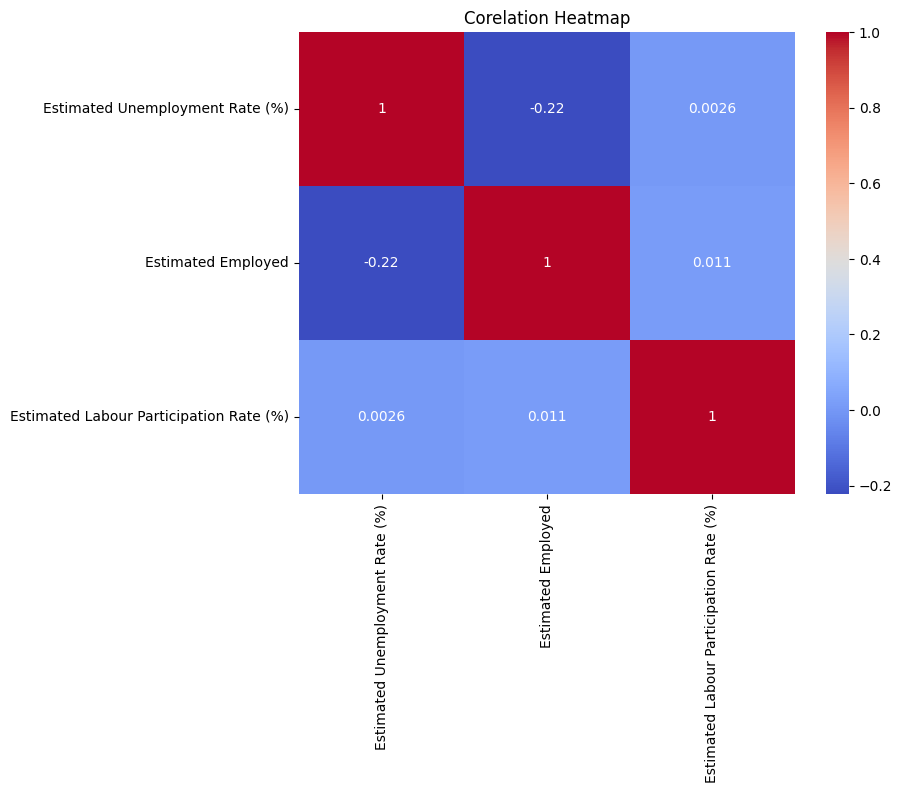

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Corelation Heatmap")
plt.show()

### step 16:top 10 regions with highest unemployment

top_regions=region_unemployment.head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_regions.values,
    y=top_regions.index
)

plt.title("Top 10 Regions with Highest Unemployment")
plt.xlabel("Average Unemployment Rate(%)")

plt.show()

### step 17:covid-19 impact analysis

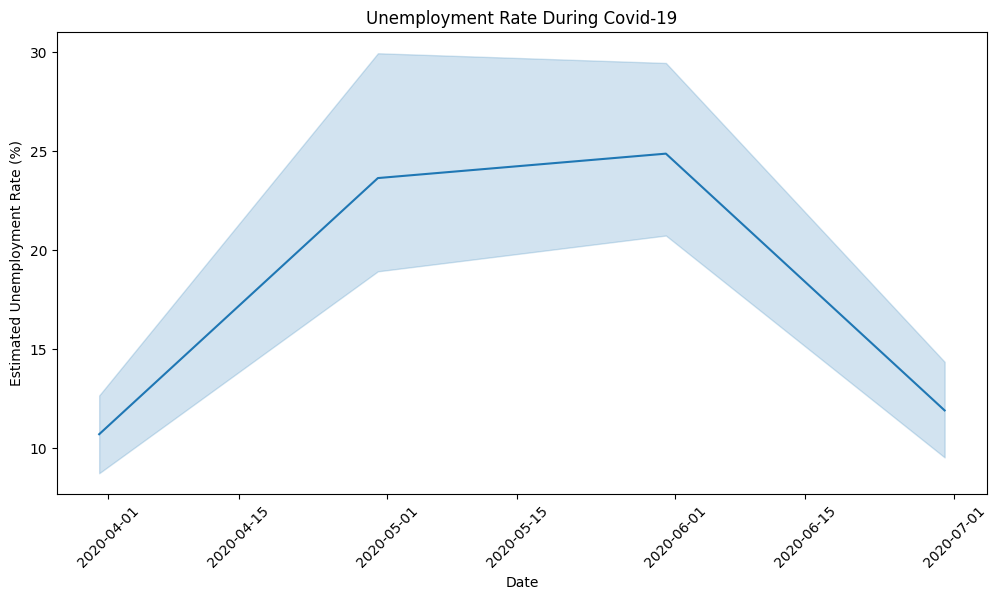

In [30]:
covid_data=df[df['Date']>='2020-03-01']
plt.figure(figsize=(12,6))
sns.lineplot(
    data=covid_data,
    x='Date',
    y='Estimated Unemployment Rate (%)'
)

plt.title("Unemployment Rate During Covid-19")
plt.xticks(rotation=45)
plt.show()

### step 18:key insights

In [31]:
print("Total records:",len(df))
print("Highest Unemployment Rate:",
     df['Estimated Unemployment Rate (%)'].max())

print("lowest Unemployment rate:",
     df['Estimated Unemployment Rate (%)'].min())

print("Average Unemployment Rate:",
     df['Estimated Unemployment Rate (%)'].mean())

Total records: 740
Highest Unemployment Rate: 76.74
lowest Unemployment rate: 0.0
Average Unemployment Rate: 11.787945945945946
